# Evaluate a trained SimpleRNN speech denoiser

This notebook **does not train the model**. It only:

1. Loads the trained PyTorch checkpoint.
2. Selects one five-second window from the TIMIT test set.
3. Adds reproducible Gaussian noise.
4. Reconstructs the window with the trained SimpleRNN.
5. Displays training curves, metrics, waveforms, spectrograms, and audio players.

## 2. Imports and paths

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
from IPython.display import Audio, display
from torch import nn

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_DIR = Path.cwd()
TEST_DIR = PROJECT_DIR / "Timit" / "Test"
MODEL_PATH = PROJECT_DIR / "outputs" / "simple_rnn_denoiser.pt"

# Change these values to evaluate another file or noise level.
EXAMPLE_INDEX = 0
EXAMPLE_SNR_DB = 5.0

print(f"Device: {DEVICE}")
print(f"Checkpoint: {MODEL_PATH.resolve()}")

Device: cpu
Checkpoint: C:\Users\USUARIO\Documents\RNN\outputs\simple_rnn_denoiser.pt


## 3. Load the checkpoint and rebuild the model

In [3]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH.resolve()}\n"
        "Run the training notebook first to create the checkpoint."
    )

# weights_only=False is appropriate here because this is our own checkpoint.
try:
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    # Compatibility with older PyTorch versions.
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

SAMPLE_RATE = checkpoint.get("sample_rate", 16_000)
SEGMENT_SECONDS = checkpoint.get("segment_seconds", 5.0)
SEGMENT_SAMPLES = int(SAMPLE_RATE * SEGMENT_SECONDS)
FRAME_LENGTH = checkpoint.get("frame_length", 256)
FRAME_STEP = checkpoint.get("frame_step", 128)
FFT_LENGTH = checkpoint.get("fft_length", 256)
N_FREQUENCIES = checkpoint.get("n_frequencies", FFT_LENGTH // 2 + 1)
RNN_UNITS = checkpoint.get("hidden_size", 128)


class SimpleRNNDenoiser(nn.Module):
    """The same architecture used in the training notebook."""

    def __init__(self, n_frequencies, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=n_frequencies,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.output_layer = nn.Linear(hidden_size, n_frequencies)

    def forward(self, noisy_magnitude):
        sequence, _ = self.rnn(noisy_magnitude)
        return torch.relu(self.output_layer(sequence))


model = SimpleRNNDenoiser(N_FREQUENCIES, RNN_UNITS).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model loaded successfully.")
print(f"Window duration: {SEGMENT_SECONDS:.1f} seconds")
print(f"Hidden units: {RNN_UNITS}")
if "test_mse" in checkpoint:
    print(f"Saved test MSE: {checkpoint['test_mse']:.6f}")

Model loaded successfully.
Window duration: 5.0 seconds
Hidden units: 128
Saved test MSE: 0.029345


## 5. Load one five-second test window and add Gaussian noise

In [5]:
def find_wav_files(folder):
    """Find test WAV files recursively."""
    if not folder.exists():
        raise FileNotFoundError(f"Test folder not found: {folder.resolve()}")

    files = sorted(
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() == ".wav"
    )

    if not files:
        raise FileNotFoundError(f"No WAV files found in: {folder.resolve()}")

    return files


def load_first_window(path):
    """Load, normalize, and pad the first window of one test recording."""
    audio, sample_rate = sf.read(
        path,
        start=0,
        frames=SEGMENT_SAMPLES,
        dtype="float32",
        always_2d=False,
    )

    if sample_rate != SAMPLE_RATE:
        raise ValueError(
            f"{path} has {sample_rate} Hz; expected {SAMPLE_RATE} Hz."
        )

    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    clean_audio = torch.from_numpy(audio)

    if len(clean_audio) < SEGMENT_SAMPLES:
        clean_audio = nn.functional.pad(
            clean_audio,
            (0, SEGMENT_SAMPLES - len(clean_audio)),
        )

    peak = clean_audio.abs().max().clamp_min(1e-8)
    return clean_audio / peak


def add_gaussian_noise(clean_audio, snr_db, seed=SEED):
    """Add reproducible Gaussian noise at the requested SNR."""
    generator = torch.Generator().manual_seed(seed)
    signal_power = clean_audio.square().mean()
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))

    noise = torch.randn(
        clean_audio.shape,
        dtype=clean_audio.dtype,
        generator=generator,
    )
    noise = noise * torch.sqrt(noise_power + 1e-10)
    return (clean_audio + noise).clamp(-1.0, 1.0)


test_files = find_wav_files(TEST_DIR)

if not 0 <= EXAMPLE_INDEX < len(test_files):
    raise IndexError(
        f"EXAMPLE_INDEX must be between 0 and {len(test_files) - 1}."
    )

example_path = test_files[EXAMPLE_INDEX]
clean_audio = load_first_window(example_path)
noisy_audio = add_gaussian_noise(clean_audio, EXAMPLE_SNR_DB)

print(f"Test file: {example_path.name}")
print(f"Window: 0.0 to {SEGMENT_SECONDS:.1f} seconds")
print(f"Gaussian-noise SNR: {EXAMPLE_SNR_DB:.1f} dB")

Test file: fadg0.wav
Window: 0.0 to 5.0 seconds
Gaussian-noise SNR: 5.0 dB


## 6. Reconstruct the window with the trained model

In [6]:
STFT_WINDOW = torch.hann_window(FRAME_LENGTH)


def stft(audio):
    """Compute the complex STFT."""
    return torch.stft(
        audio,
        n_fft=FFT_LENGTH,
        hop_length=FRAME_STEP,
        win_length=FRAME_LENGTH,
        window=STFT_WINDOW.to(audio.device),
        return_complex=True,
    )


def denoise_window(model, noisy_audio):
    """Estimate and reconstruct one five-second window."""
    noisy_audio = noisy_audio.to(DEVICE)
    noisy_stft = stft(noisy_audio)
    noisy_magnitude = noisy_stft.abs()

    # Convert [frequency, time] into [batch, time, frequency].
    rnn_input = noisy_magnitude.transpose(0, 1).unsqueeze(0)

    with torch.no_grad():
        predicted_magnitude = model(rnn_input)[0].transpose(0, 1)

    noisy_phase = noisy_stft / (noisy_magnitude + 1e-8)
    predicted_stft = predicted_magnitude * noisy_phase

    reconstructed = torch.istft(
        predicted_stft,
        n_fft=FFT_LENGTH,
        hop_length=FRAME_STEP,
        win_length=FRAME_LENGTH,
        window=STFT_WINDOW.to(DEVICE),
        length=SEGMENT_SAMPLES,
    )
    return reconstructed.clamp(-1.0, 1.0).cpu()


denoised_audio = denoise_window(model, noisy_audio)
print("Reconstruction complete.")

Reconstruction complete.


## 7. Numerical results

A useful denoiser should reduce MSE and increase SNR relative to the noisy input.

In [7]:
def mse(reference, estimate):
    return torch.mean((reference - estimate) ** 2).item()


def signal_to_noise_ratio(reference, estimate):
    signal_power = torch.sum(reference ** 2)
    error_power = torch.sum((reference - estimate) ** 2).clamp_min(1e-12)
    return (10.0 * torch.log10(signal_power / error_power)).item()


noisy_mse = mse(clean_audio, noisy_audio)
denoised_mse = mse(clean_audio, denoised_audio)
noisy_snr = signal_to_noise_ratio(clean_audio, noisy_audio)
denoised_snr = signal_to_noise_ratio(clean_audio, denoised_audio)

print(f"Noisy MSE:       {noisy_mse:.6f}")
print(f"Denoised MSE:    {denoised_mse:.6f}")
print(f"Noisy SNR:       {noisy_snr:.2f} dB")
print(f"Denoised SNR:    {denoised_snr:.2f} dB")
print(f"SNR improvement: {denoised_snr - noisy_snr:+.2f} dB")

Noisy MSE:       0.003974
Denoised MSE:    0.000800
Noisy SNR:       4.94 dB
Denoised SNR:    11.91 dB
SNR improvement: +6.96 dB


## 8. Listen to the results

In [8]:
print("Clean audio")
display(Audio(clean_audio.numpy(), rate=SAMPLE_RATE))

print("Audio with Gaussian noise")
display(Audio(noisy_audio.numpy(), rate=SAMPLE_RATE))

print("SimpleRNN reconstruction")
display(Audio(denoised_audio.numpy(), rate=SAMPLE_RATE))

Clean audio


Audio with Gaussian noise


SimpleRNN reconstruction


## 9. Compare the waveforms

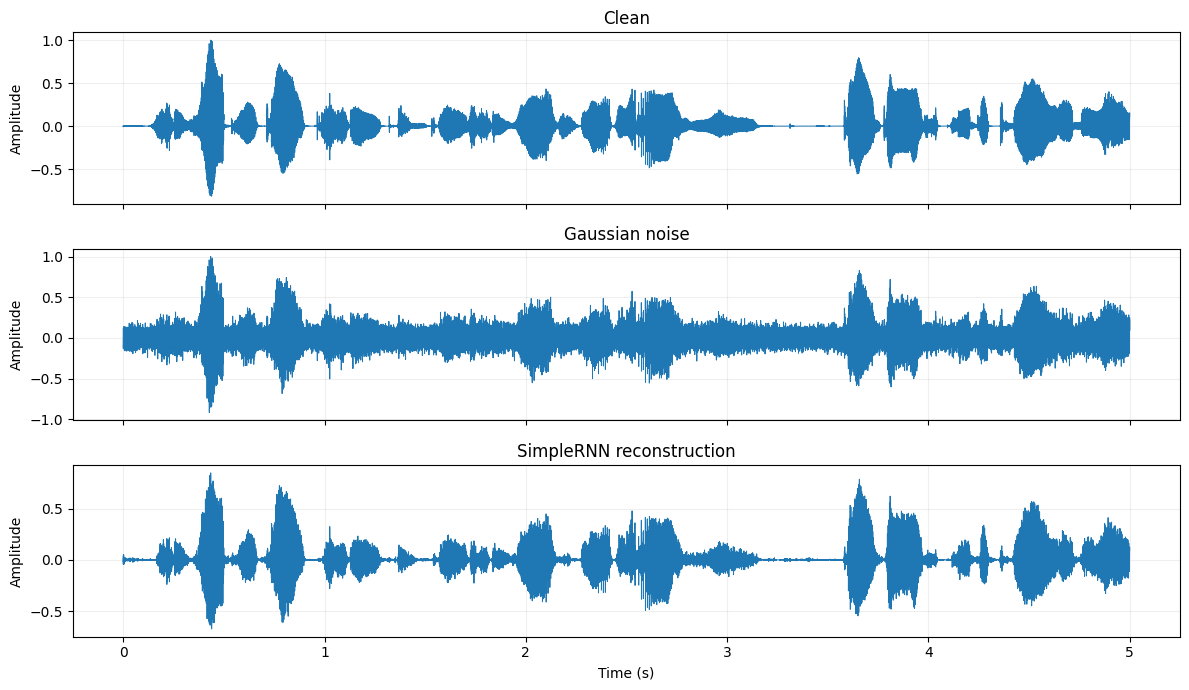

In [9]:
time = np.arange(SEGMENT_SAMPLES) / SAMPLE_RATE
signals = [
    (clean_audio.numpy(), "Clean"),
    (noisy_audio.numpy(), "Gaussian noise"),
    (denoised_audio.numpy(), "SimpleRNN reconstruction"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for axis, (signal, title) in zip(axes, signals):
    axis.plot(time, signal, linewidth=0.7)
    axis.set_title(title)
    axis.set_ylabel("Amplitude")
    axis.grid(alpha=0.2)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 10. Compare the spectrograms

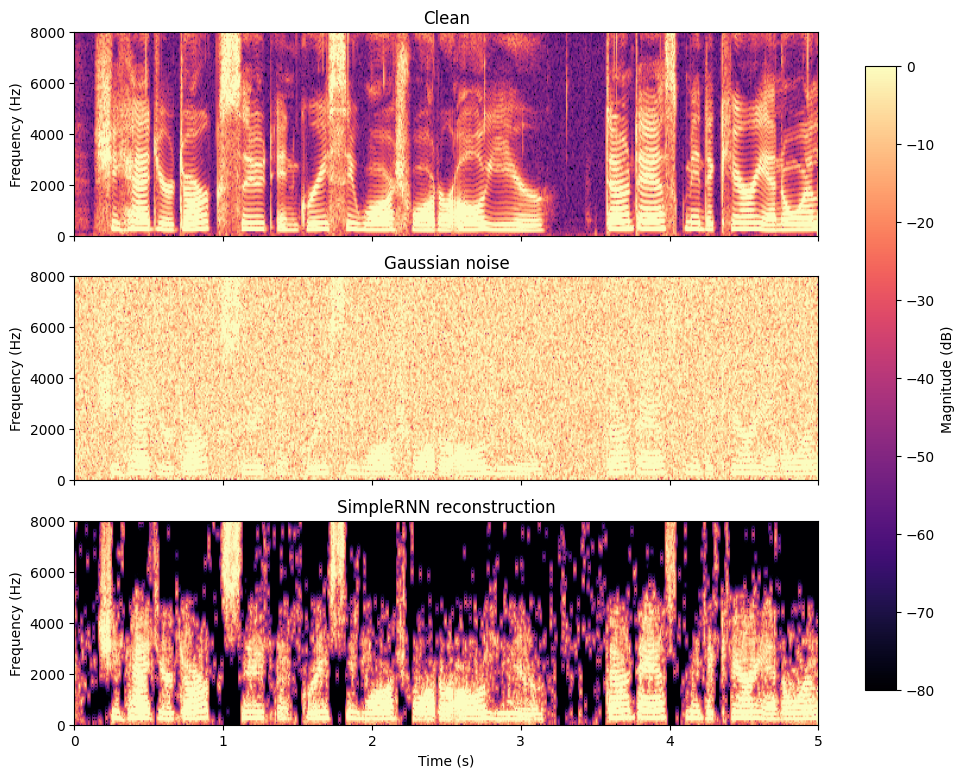

In [10]:
def log_spectrogram(audio):
    """Return a log-magnitude spectrogram for visualization."""
    magnitude = stft(audio).abs()
    return 20.0 * torch.log10(magnitude.clamp_min(1e-5))


spectrograms = [
    (log_spectrogram(clean_audio).cpu().numpy(), "Clean"),
    (log_spectrogram(noisy_audio).cpu().numpy(), "Gaussian noise"),
    (log_spectrogram(denoised_audio).cpu().numpy(), "SimpleRNN reconstruction"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for axis, (spectrogram, title) in zip(axes, spectrograms):
    image = axis.imshow(
        spectrogram,
        origin="lower",
        aspect="auto",
        extent=[0, SEGMENT_SECONDS, 0, SAMPLE_RATE / 2],
        cmap="magma",
        vmin=-80,
        vmax=0,
    )
    axis.set_title(title)
    axis.set_ylabel("Frequency (Hz)")

axes[-1].set_xlabel("Time (s)")
fig.colorbar(image, ax=axes, label="Magnitude (dB)", shrink=0.9)
plt.show()